# **Generate the input pickle file from the glacier image for the simulation**
This notebook generates the requiered pickle file for the simulation of the bottom topography of the Tsanfleuron glacier.

### **Input** : 
* path to the training image of the glacier in a tiff format.
* path to the glacier mask in a tiff format.
* path to the GPR point set csv

### **Output** : 
* .pickle binary files to be open with the simulation script

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd
import georasters as gr
import time 
from random import seed
seed(1)
from random import random
import csv


import tkinter as tk
from tkinter import filedialog

C:\Users\wdall\Anaconda3\envs\tsanfleuron_w\lib\site-packages\pysal\explore\segregation\network\network.py:16: UserWarning: You need pandana and urbanaccess to work with segregation's network module
You can install them with  `pip install urbanaccess pandana` or `conda install -c udst pandana urbanaccess`
  "You need pandana and urbanaccess to work with segregation's network module\n"
C:\Users\wdall\Anaconda3\envs\tsanfleuron_w\lib\site-packages\pysal\model\spvcm\abstracts.py:10: UserWarning: The `dill` module is required to use the sqlite backend fully.
  from .sqlite import head_to_sql, start_sql


## Import the data 
The DEM will be put in the same grid than the simulation grid (mask grid), in order to ease the volume estimation after the simulations. (ON PEUT REMOVE LE DEM)

In [9]:
file_path_ti      = '../../../../../99_Data/tsanfleuron/ti_cyprien.tif'
file_path_glacier = '../../../../../99_Data/tsanfleuron/dem_glacier_cyprien.tif'
file_path_mask    = '../../../../../99_Data/tsanfleuron/mask_glacier.tif'

if os.path.isfile(file_path_ti):
    print('Le fichier est présent. import')
    data_ti = gr.from_file(file_path_ti)
    (xmin, xsize, x, ymax, y, ysize) = data_ti.geot

else:
    print('error')

    
if os.path.isfile(file_path_glacier):
    print('Le fichier est présent. import')
    data_dem = gr.from_file(file_path_glacier
                           )

else:
    print('error')
    
    
if os.path.isfile(file_path_mask):
    print('Le fichier est présent. import')
    data_mask = gr.from_file(file_path_mask
                           )

else:
    print('error')


    
print('\nInfos')
print('DEM geometry :' + str(data_ti.geot))
print('DEM shape :'+ str(data_ti.shape))

Le fichier est présent. import
Le fichier est présent. import
Le fichier est présent. import

Infos
DEM geometry :(582132.0, 2.0, 0.0, 131232.0, 0.0, -2.0)
DEM shape :(1566, 3531)


In [10]:
data_dem.raster.data[data_mask.raster!=1] =np.nan

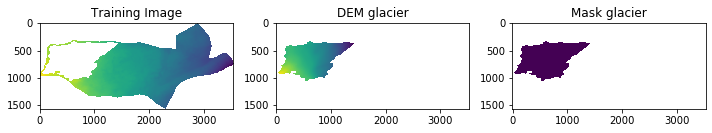

In [11]:
data_ti.raster.data[data_ti.raster==data_ti.min()]=np.nan

plt.subplots(1,3,figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(data_ti.raster)
plt.title('Training Image')
plt.subplot(1,3,2)
plt.imshow(data_dem.raster)
plt.title('DEM glacier')
plt.subplot(1,3,3)
plt.imshow(data_mask.raster)
plt.title('Mask glacier')
plt.tight_layout()
plt.show()

In [12]:
#Import the point set hard data
path_csv = '../data/PointSet/csv/'
Hard_GPR = pd.read_csv(path_csv+'bedRock_GPR.csv',delimiter =';')
#Hard_MNT = pd.read_csv(path_csv+'bedRock_MNT.csv',delimiter='\t')

## We create a new mask/mesh that regroupe the glacier and the ti and clean the hard data set

In [13]:
#Create a mesh grid witht the dimension of the DEM ### c'est pour faire quoi?
x_v = np.array(range(data_ti.shape[1]))*data_ti.geot[1] + data_ti.geot[0]
y_v = np.array(range(data_ti.shape[0]))*data_ti.geot[5] + data_ti.geot[3]
X_dem, Y_dem = np.meshgrid(x_v,y_v)

In [14]:
#Clean the point Set data to the geometry of the mask  ### c'est bien ça, tu clean les hard data?

#Hard_pts = Hard_MNT.append(Hard_GPR[['X','Y','Bed_Alt']])
Hard_pts = Hard_GPR.copy()
borders  = [X_dem.min(),X_dem.max(),Y_dem.min(),Y_dem.max(), Hard_pts['X'].min(), Hard_pts['X'].max(),Hard_pts['Y'].min(), Hard_pts['Y'].max()]

x_min = min(borders[0],borders[4])
x_max = max(borders[1],borders[5])
y_min = min(borders[2],borders[6])
y_max = max(borders[3],borders[7])

nx = np.int(np.ceil((x_max - x_min)/2))
ny = np.int(np.ceil((y_max - y_min)/2))
referential = [x_min, y_max]

#Add to the data frame the cell_x and cell_y coordinate
Hard_pts.insert(0,'cell_x',np.around((Hard_pts['X']-referential[0])/data_ti.geot[1],decimals=0))
Hard_pts.insert(1,'cell_y',np.around((Hard_pts['Y']-referential[1])/data_ti.geot[5],decimals=0))

#Remove the points that share the same cell_x and cell_y
Hard_pts = Hard_pts.drop_duplicates(subset = ['cell_x','cell_y'] )
Hard_pts.rename(columns={'Bed_Alt':'alt'}, inplace=True)
Hard_pts = Hard_pts.drop(columns=['depth','Z'])

In [15]:
Hard_pts.head()

,cell_x,cell_y,X,Y,alt
0,136.0,357.0,582404.5841,130518.0406,2792.731
1,132.0,350.0,582395.5218,130531.0831,2799.314
2,142.0,368.0,582416.0519,130495.6199,2788.426
3,148.0,378.0,582428.2737,130475.9283,2788.680
4,150.0,381.0,582432.0730,130470.5054,2791.285


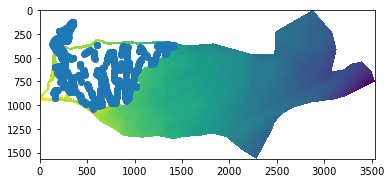

In [16]:
plt.imshow(data_ti.raster)
plt.scatter(Hard_pts.cell_x,Hard_pts.cell_y)
plt.show()

## We create the output data

In [17]:
#Training image
ti = np.copy(data_ti.raster.data)
ti[ti==-1] = np.nan

In [18]:
#Mask glacier
mask_glacier = np.copy(data_mask.raster.data)
mask_glacier[mask_glacier!=1]=0

In [19]:
#Mask large
mask_large = np.copy(ti)
mask_large[mask_large>0]=1
mask_large[mask_large!=1]=0
mask_large[mask_glacier==1]=1

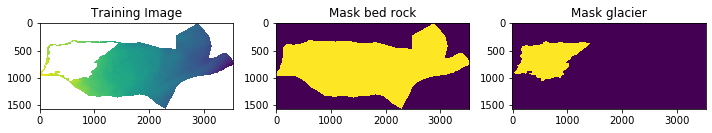

In [20]:
plt.subplots(1,3,figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(ti)
plt.title('Training Image')
plt.subplot(1,3,2)
plt.imshow(mask_large)
plt.title('Mask bed rock')
plt.subplot(1,3,3)
plt.imshow(mask_glacier)
plt.title('Mask glacier')
plt.tight_layout()
plt.show()

## Remove the trend in the data

In [190]:
from scipy import interpolate
X = np.arange(0, ti.shape[0],1)
Y = np.arange(0, ti.shape[1],1)
z = np.copy(ti.flatten())
nan_map = np.zeros_like( z )
nan_map[ np.isnan(z) ] = 1

filled_z = z.copy()
filled_z[ np.isnan(z) ] = 0

In [199]:
xx,yy = np.meshgrid(Y,X)

In [200]:
xx.shape, yy.shape, ti.shape

((1566, 3531), (1566, 3531), (1566, 3531))

In [282]:
X_ti = np.array([[x,y] for x,y in zip(xx[ti>0],yy[ti>0])])
Y_ti = np.array([z for z in ti[ti>0]])
print(len(X_ti))

2228080


In [280]:
X_GPR = np.array([[x,y] for x,y in zip(Hard_pts.cell_x,Hard_pts.cell_y)])
Y_GPR = np.array(Hard_pts.alt)
print(len(X_GPR))

1513


In [287]:
X = np.concatenate([X_ti,X_GPR])
Y = np.concatenate([Y_ti,Y_GPR])

In [288]:
from sklearn.linear_model import LinearRegression as lr 

In [289]:
#Linear regression model
regLinear = lr().fit(X,Y)
regLinear.score(X,Y), regLinear.coef_

(0.9765386350796683, array([-0.24982926, -0.02195245]))

In [292]:
trend_ti = regLinear.predict(X_ti)
new_ti   = np.copy(ti)
new_ti[ti>0]=new_ti[ti>0]-trend_ti

In [302]:
trend_GPR = regLinear.predict(X_GPR)
new_pts = Hard_pts.copy()
new_pts.alt = new_pts.alt-trend_GPR

In [304]:
new_pts.head()

,cell_x,cell_y,X,Y,alt
0,136.0,357.0,582404.5841,130518.0406,-111.547724
1,132.0,350.0,582395.5218,130531.0831,-106.117708
2,142.0,368.0,582416.0519,130495.6199,-114.112271
3,148.0,378.0,582428.2737,130475.9283,-112.139771
4,150.0,381.0,582432.0730,130470.5054,-108.969255


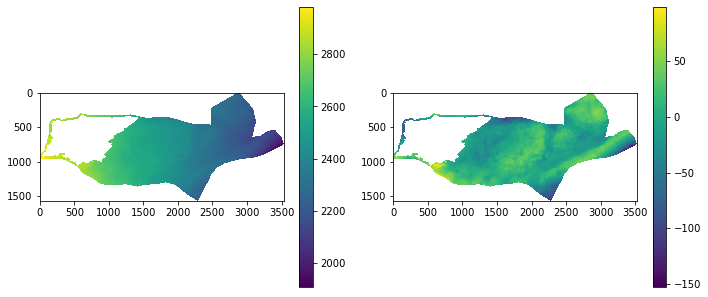

In [291]:
plt.subplots(1,2,figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(ti)
plt.colorbar(shrink=0.4)
plt.subplot(1,2,2)
plt.imshow(new_ti)
plt.colorbar(shrink=0.4)
plt.tight_layout()
plt.show()

## We export the data for the simulations

In [24]:
#Clear and create the empty directory for the pickle file
save_path   = '../real_data'

if not(os.path.exists(save_path)):
    os.mkdir(save_path)
else:
    for root, dirs, files in os.walk(save_path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
        
    os.rmdir(save_path)
    os.mkdir(save_path)

In [25]:
#Save the data
#The data are : [true Mnt, position of the mask, hard_data, ti, [mask_glacier, mask_glacier+ti]
with open(save_path + '/' + 'tsanfleuron_data' + '.pickle', 'wb') as f:  # Python 3: open(..., 'wb')
    pickle.dump([None, [0,nx+1,0,ny+1], Hard_pts,ti,[mask_large,mask_glacier],referential], f, pickle.HIGHEST_PROTOCOL)

### Brouillon

In [65]:
with open('../real_data/tsanfleuron_data.pickle','rb')as f:
    t = pickle.load(f)

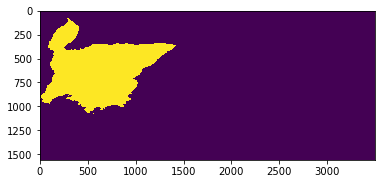

In [106]:
plt.imshow(t[4][0])

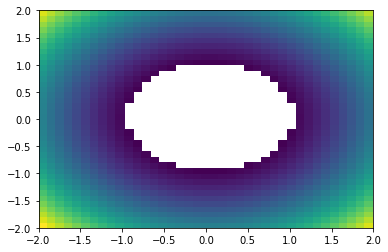

In [152]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from scipy.interpolate import interp2d

# Generate some test data:
x = np.linspace(-2, 2, 40)
y = np.linspace(-2, 2, 41)
xx, yy = np.meshgrid(x, y)

z = xx**2+yy**2
z[ xx**2+yy**2<1 ] = np.nan
plt.pcolor(x,y,z)


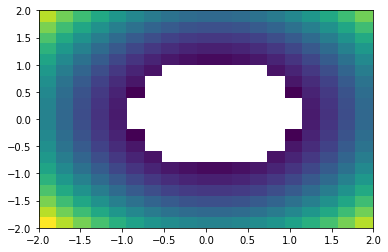

In [151]:
# Interpolation functions:
nan_map = np.zeros_like( z )
nan_map[ np.isnan(z) ] = 1

filled_z = z.copy()
filled_z[ np.isnan(z) ] = 0

f = interp2d(x, y, filled_z, kind='linear')
f_nan = interp2d(x, y, nan_map, kind='linear')     

# Interpolation on new points:
xnew = np.linspace(-2, 2, 20)
ynew = np.linspace(-2, 2, 21)

z_new = f(xnew, ynew)
nan_new = f_nan( xnew, ynew )
z_new[ nan_new>0.5 ] = np.nan

plt.pcolor(xnew, ynew, z_new)